# Figure: Shorkie LM self-attention map over a gene locus

This notebook visualizes the relative-position self-attention learned by the **Shorkie language model (Shorkie LM)** across a 16,384-bp window centered on a yeast gene. For a chosen transformer block (and averaging over heads), it renders the token-by-token attention matrix (`attended-on` vs `attended-by`, both in 128-bp bins) as a heatmap, with the gene/exon/UTR annotations overlaid. The map reveals that attention concentrates within gene bodies and around regulatory boundaries (TSS / UTRs).

**Reproduces:** the per-layer attention-map panel of the Shorkie LM attention-map figure.

**Upstream:** Runs end-to-end from released data — the Shorkie LM weights and the R64 genome. No precomputed attention tensor is needed (an optional cache is documented under `results.attention`).

**Requires:** the `yeast_ml` conda environment with `pip install -e .` (provides `shorkie`, plus `baskerville`, `tensorflow`, `pysam`, `pyranges`). A GPU is optional — the source script forces CPU (`CUDA_VISIBLE_DEVICES=-1`); a single forward pass over 16 kb is feasible on CPU.

**Source script:** `scripts/04_analysis/shorkie_lm/attention_map/1_visualize_attention.py` (LM mode, `--LM_exp`, `attention_offset=74`).

In [1]:
import gc
import json
import os

# Mirror the source script: extract attention on CPU to keep memory predictable.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pysam
import pyranges as pr
import tensorflow as tf
from baskerville import seqnn, layers
from baskerville import gene as bgene

tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Real shorkie helpers used below (sequence one-hot + annotation extraction).
from shorkie import config
from shorkie.helpers.yeast_helpers import process_sequence  # noqa: F401  (used via wrapper)

2026-06-19 05:17:45.793625: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 05:17:45.837735: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 05:17:45.837760: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 05:17:45.838847: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 05:17:45.845566: I tensorflow/core/platform/cpu_feature_guar

2026-06-19 05:17:46.654158: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# --- Path resolution via shorkie.config (never hardcode absolute paths) ---
lm_dir       = config.path('models.shorkie_lm')
params_file  = str(lm_dir / 'train' / 'params.json')
model_file   = str(lm_dir / 'train' / 'model_best.h5')
fasta_file   = str(config.path('genome.fasta'))
gtf_file     = str(config.path('genome.gtf'))

print('LM params :', params_file)
print('LM weights:', model_file)
print('genome    :', fasta_file)
print('gtf       :', gtf_file)

LM params : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/lm_experiment/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI/LM_Johannes/lm_saccharomycetales_gtf/lm_saccharomycetales_gtf_unet_small_bert_drop/train/params.json
LM weights: /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/lm_experiment/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI/LM_Johannes/lm_saccharomycetales_gtf/lm_saccharomycetales_gtf_unet_small_bert_drop/train/model_best.h5
genome    : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/data/yeast/ensembl_fungi_59/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI/data_r64_gtf/fasta/GCA_000146045_2.cleaned.fasta
gtf       : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/data/yeast/ensembl_fungi_59/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI/data_r64_gtf/gtf/GCA_000146045_2.59.gtf


In [3]:
# --- Load the Shorkie LM (single fold) ---
# The LM input has 4 DNA channels + (165 species + 1) identity channels.
NUM_SPECIES = 165
SEQ_LEN = 16384
ATTENTION_OFFSET = 74   # first transformer block index inside the trunk (LM unet_small_bert_drop)
LAYER_STEP = 11         # stride between successive attention blocks
N_LAYERS = 8            # number of transformer blocks in the LM trunk

with open(params_file) as fh:
    params = json.load(fh)
params_model = params['model']
params_model['num_features'] = NUM_SPECIES + 5   # LM channel count (DNA + species)
params_model['seq_length'] = SEQ_LEN

tf.keras.backend.clear_session()
seqnn_model = seqnn.SeqNN(params_model)
seqnn_model.restore(model_file, trunk=False)
print('Loaded Shorkie LM.')

2026-06-19 05:17:47.892411: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:b1:00.0, compute capability: 8.0


Model: "model_1"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 sequence (InputLayer)       [(None, 16384, 170)]         0         []                            


...

  Weight separable_conv1d_4/separable_conv1d_4/bias:0: (384,)


  Weight separable_conv1d_4/separable_conv1d_4/depthwise_kernel:0: (3, 384, 1)
  Weight separable_conv1d_4/separable_conv1d_4/pointwise_kernel:0: (1, 384, 384)


  Weight separable_conv1d_5/separable_conv1d_5/bias:0: (384,)


  Weight separable_conv1d_5/separable_conv1d_5/depthwise_kernel:0: (3, 384, 1)
  Weight separable_conv1d_5/separable_conv1d_5/pointwise_kernel:0: (1, 384, 384)
  Weight separable_conv1d_6/separable_conv1d_6/bias:0: (384,)
  Weight separable_conv1d_6/separable_conv1d_6/depthwise_kernel:0: (3, 384, 1)
  Weight separable_conv1d_6/separable_conv1d_6/pointwise_kernel:0: (1, 384, 384)
model_file =  /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/lm_experiment/test_chrXI_chrXIII_chrXV__valid_chrXII_chrXIV_chrXVI/LM_Johannes/lm_saccharomycetales_gtf/lm_saccharomycetales_gtf_unet_small_bert_drop/train/model_best.h5
by_name =  True
head_i =  0
trunk =  False
by_name =  True
Trying to load weights by name
self.models[head_i]:  <keras.src.engine.functional.Functional object at 0x1553d8fe9210>


*** Successfully loaded weights by name
Loaded Shorkie LM.


In [4]:
# --- Attention extraction (ported from the source script) ---
# These low-level helpers reimplement the relative-position MHSA softmax using
# baskerville layer internals; they are NOT part of the public shorkie API, so we
# keep them inline here rather than inventing a shorkie symbol.

def _get_attention_weights(self, inputs, training=False):
    seq_len = inputs.shape[1]
    q = self._multihead_output(self._q_layer, inputs)
    k = self._multihead_output(self._k_layer, inputs)
    if self._scaling:
        q *= self._key_size ** -0.5
    content_logits = tf.matmul(q + self._r_w_bias, k, transpose_b=True)
    if self._num_position_features == 0:
        logits = content_logits
    else:
        distances = tf.range(-seq_len + 1, seq_len, dtype=tf.float32)[tf.newaxis]
        positional_encodings = layers.positional_features(
            positions=distances,
            feature_size=self._num_position_features,
            seq_length=seq_len,
            symmetric=self._relative_position_symmetric,
        )
        r_k = self._multihead_output(self._r_k_layer, positional_encodings)
        if self._content_position_bias:
            relative_logits = tf.matmul(q + self._r_r_bias, r_k, transpose_b=True)
        else:
            relative_logits = tf.matmul(self._r_r_bias, r_k, transpose_b=True)
            relative_logits = tf.broadcast_to(
                relative_logits, shape=(1, self._num_heads, seq_len, 2 * seq_len - 1))
        relative_logits = layers.relative_shift(relative_logits)
        logits = content_logits + relative_logits
    return tf.nn.softmax(logits)


def get_attention_model(model, layer_ix, inital_offset=ATTENTION_OFFSET, offset=LAYER_STEP):
    """Keras model that outputs attention weights of transformer block `layer_ix`.

    The released LM restores as a single FLAT Keras model (no nested trunk submodel):
    its MultiheadAttention blocks sit at top-level indices inital_offset+offset*layer_ix
    (74, 85, ..., 151 -- verified by introspection), each fed by the LayerNormalization
    immediately before it. model.model.layers[1] is the StochasticShift augmentation
    layer (NOT a trunk submodel), so we index model.model directly.
    """
    km = model.model
    idx = inital_offset + offset * layer_ix
    mhsa = km.layers[idx]
    assert "MultiheadAttention" in type(mhsa).__name__, (
        f"expected MultiheadAttention at layer {idx}, got {type(mhsa).__name__}")
    return tf.keras.Model(km.inputs, _get_attention_weights(mhsa, km.layers[idx - 1].output))

In [5]:
# --- Choose a gene and build the model input via shorkie helpers ---
SEARCH_GENE = 'YGL076C'   # one representative gene from the source script's gene_ls

gene_pr = pr.read_gtf(gtf_file)
gene_pr = gene_pr[gene_pr.Feature.isin(['gene', 'exon', 'five_prime_UTR', 'three_prime_UTR'])]
transcriptome = bgene.Transcriptome(gtf_file)
fasta_open = pysam.Fastafile(fasta_file)

# The Ensembl GTF names chromosomes in bare Roman ('VII'); the FASTA uses 'chrVII'.
# Remap BOTH the fetch chrom and the annotation PyRanges, because process_sequence
# uses chrom for make_seq_1hot AND filters gene_pr by Chromosome == chrom.
fasta_refs = set(fasta_open.references)
def to_fasta_chrom(c):
    c = str(c)
    for cand in (c, "chr" + c, c.replace("chr", ""), "chr" + c.replace("chr", "")):
        if cand in fasta_refs:
            return cand
    return c
gene_pr = pr.PyRanges(
    gene_pr.df.assign(Chromosome=gene_pr.df.Chromosome.astype(str).map(to_fasta_chrom))
)

gene_key = [k for k in transcriptome.genes if SEARCH_GENE in k][0]
gene = transcriptome.genes[gene_key]
gene_start = gene.get_exons()[0][0]
gene_end = gene.get_exons()[-1][1]
center = (gene_start + gene_end) // 2
start, end = center - SEQ_LEN // 2, center + SEQ_LEN // 2
chrom = to_fasta_chrom(gene.chrom)
print(f'{SEARCH_GENE}: {chrom}:{start}-{end}')

# shorkie.helpers.yeast_helpers.process_sequence -> (seq one-hot with species channel, annotation_df)
sequence_one_hot, annotation_df = process_sequence(
    fasta_open, chrom, start, end, gene_pr, seq_len=SEQ_LEN, model_type='LM'
)
sequence_one_hot = np.asarray(sequence_one_hot, dtype='float32')
print('input shape:', sequence_one_hot.shape)

YGL076C: chrVII:356973-373357
In process_sequence, model_type: LM
make_seq_1hot  chrVII 356973 373357 16384
sequence_one_hot.shape = (16384, 4)
x_new.shape = (16384, 170)
x_new.shape = (16384, 170)
input shape: (16384, 170)


In [6]:
# --- Forward pass: attention per transformer block, averaged fwd + reverse-complement ---
LAYER_INDEX = [5, 6]   # two penultimate blocks, as in the source script default
SCORE_RC = True

layer_maps = []
for layer_ix in LAYER_INDEX:
    att_model = get_attention_model(seqnn_model, layer_ix=layer_ix)
    att = att_model.predict(x=[sequence_one_hot[None, ...]], batch_size=1)  # (1, H, T, T)
    if SCORE_RC:
        att_rc = att_model.predict(x=[sequence_one_hot[None, ::-1, ::-1]], batch_size=1)
        att = 0.5 * (att + att_rc[..., ::-1, ::-1])
    layer_maps.append(att[0])  # (H, T, T)
    del att_model
    gc.collect()

# Average over selected layers and over all heads -> (T, T) attention matrix.
att_matrix = np.mean(np.mean(np.stack(layer_maps, axis=0), axis=0), axis=0)
print('attention matrix shape:', att_matrix.shape)

2026-06-19 05:17:53.248605: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


2026-06-19 05:17:55.348162: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-06-19 05:17:55.443420: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 2s 2s/step


1/1 [==============================] - ETA: 0s

...

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 1s 1s/step


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 25ms/step


attention matrix shape: (128, 128)


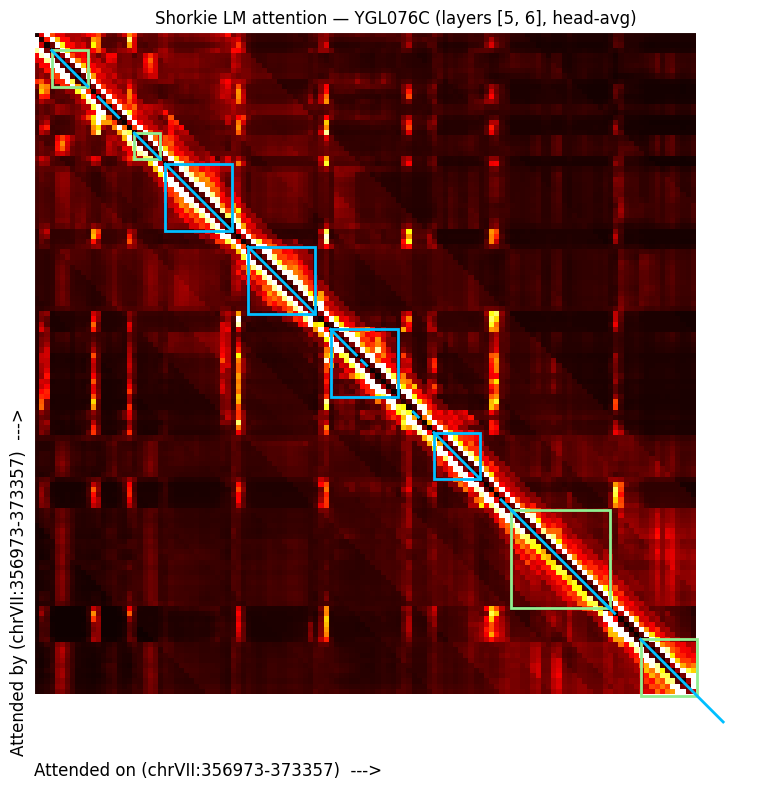

In [7]:
# --- Plot the attention heatmap with gene/exon/UTR annotations (ported from plot_attention_score) ---
VMIN, VMAX = 0.001, 0.05
BIN_BP = 128
atten_size = att_matrix.shape[0]

att = att_matrix.copy()
att[att < VMIN] = 0.0

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(att, cmap='hot', vmin=VMIN, vmax=VMAX, aspect='equal')

annotate_features = [
    {'feature': 'gene', 'filter_query': "Strand == '+'", 'plot_type': 'box', 'color': 'lightgreen', 'min_len': 500},
    {'feature': 'gene', 'filter_query': "Strand == '-'", 'plot_type': 'box', 'color': 'deepskyblue', 'min_len': 500},
    {'feature': 'five_prime_UTR', 'filter_query': None, 'plot_type': 'line', 'color': 'magenta', 'min_len': 0},
    {'feature': 'three_prime_UTR', 'filter_query': None, 'plot_type': 'line', 'color': 'magenta', 'min_len': 0},
    {'feature': 'exon', 'filter_query': None, 'plot_type': 'line', 'color': 'deepskyblue', 'min_len': 0},
]

for spec in annotate_features:
    q = "Feature == '" + spec['feature'] + "'"
    if spec['filter_query']:
        q += ' and ' + spec['filter_query']
    fdf = annotation_df.query(q)
    for _, row in fdf.iterrows():
        if (row['End'] - row['Start']) < spec['min_len']:
            continue
        sb = (row['Start'] - start) // BIN_BP
        eb = (row['End'] - start) // BIN_BP
        if spec['plot_type'] == 'box':
            side = min(eb - sb, atten_size - sb)
            ax.add_patch(patches.Rectangle((sb, sb), side, side, linewidth=2,
                                           edgecolor=spec['color'], facecolor='none'))
        else:  # diagonal line marker for exon / UTR
            ax.plot([sb, eb], [sb, eb], linewidth=2, color=spec['color'])

ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_edgecolor('white')
ax.set_xlabel(f'Attended on ({chrom}:{start}-{end})  --->', fontsize=12, loc='left')
ax.set_ylabel(f'Attended by ({chrom}:{start}-{end})  --->', fontsize=12, loc='bottom')
ax.set_title(f'Shorkie LM attention — {SEARCH_GENE} (layers {LAYER_INDEX}, head-avg)', fontsize=12)
plt.tight_layout()
plt.show()